In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/11011
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  2622.839208203568
RUN  2 , total integrated cost =  1696.0152175305707
RUN  3 , total integrated cost =  961.28709583026
RUN  4 , total integrated cost =  919.2962057294297
RUN  5 , total integrated cost =  881.3194145216924
RUN  6 , total integrated cost =  854.7030837772649
RUN  7 , total integrated cost =  829.9761160267154
RUN  8 , total integrated cost =  810.8758437721841
RUN  9 , total integrated cost =  793.7673895087071
RUN  10 , total integrated cost =  779.3380183430916
RUN  11 , total integrated cost =  766.6134584803671
RUN  12 , total integrated cost =  755.1784785850692
RUN  13 , total integrated cost =  745.2164040144185
RUN  14 , total integrated cost =  735.8155353618238
RUN  15 , total integrated cost =  727.6914136519373
RUN  16 , tota

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  348 , total integrated cost =  525.0688721076955
Improved over  348  iterations in  37.012339701876044  seconds by  91.10415600900046  percent.
Problem in initial value trasfer:  Vmean_exc -64.71235036049283 -64.71054299068308
weight =  112.41204331053463
set cost params:  1.0 112.41204331053463 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5888.823921820943
Gradient descend method:  None
RUN  1 , total integrated cost =  5866.967749171153
RUN  2 , total integrated cost =  5866.924106804089
RUN  3 , total integrated cost =  5866.91835975679
RUN  4 , total integrated cost =  5866.9182719215705
RUN  5 , total integrated cost =  5866.918262227469
RUN  6 , total integrated cost =  5866.918262078227
RUN  7 , total integrated cost =  5866.9182620782185


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  5866.918262078207
RUN  9 , total integrated cost =  5866.918262078207
Control only changes marginally.
RUN  9 , total integrated cost =  5866.918262078207
Improved over  9  iterations in  1.3128546513617039  seconds by  0.37198700510580807  percent.
Problem in initial value trasfer:  Vmean_exc -63.766623938225095 -63.79226291154281
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  14810.043540085586
RUN  2 , total integrated cost =  14768.487106207625
RUN  3 , total integrated cost =  14767.215815776395
RUN  4 , total integrated cost =  14767.077107583631
RUN  5 , total integrated cost =  14767.03085772592
RUN  6 , total integrated cost =  14767.02476855238
RUN  7 , total integrated cost =  14767.006569507197
RUN  8 , total integrated cost =  14767.000164830195
RUN  

...

RUN  5 , total integrated cost =  13890.95773511222
Control only changes marginally.
RUN  5 , total integrated cost =  13890.95773511222
Improved over  5  iterations in  0.8264280799776316  seconds by  0.0008304809948356251  percent.
Problem in initial value trasfer:  Vmean_exc -56.673681561302445 -56.67382008364185
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38613.011975189
Gradient descend method:  None
RUN  1 , total integrated cost =  37773.2651671254
RUN  2 , total integrated cost =  37758.64641767224
RUN  3 , total integrated cost =  37757.98197963479
RUN  4 , total integrated cost =  37757.80808469218
RUN  5 , total integrated cost =  37757.65355486971
RUN  6 , total integrated cost =  37757.57715194809
RUN  7 , total integrated cost =  37757.51041851221
RUN  8 , total integrated cost =  37757.456560366496
RUN  9 , total integrated cost =  37757.405797570704
RUN  10 , to

ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  37755.6870271694
Control only changes marginally.
RUN  100 , total integrated cost =  37755.6870271694
Improved over  100  iterations in  7.1927129197865725  seconds by  2.220300629669808  percent.
Problem in initial value trasfer:  Vmean_exc -56.70086418297294 -56.70082078782379
weight =  10.227071738200038
set cost params:  1.0 10.227071738200038 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37763.11167786304
Gradient descend method:  None
RUN  1 , total integrated cost =  37763.11167786303


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  37763.11167786303
Control only changes marginally.
RUN  2 , total integrated cost =  37763.11167786303
Improved over  2  iterations in  0.3319120854139328  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.70086418297296 -56.70082078782379


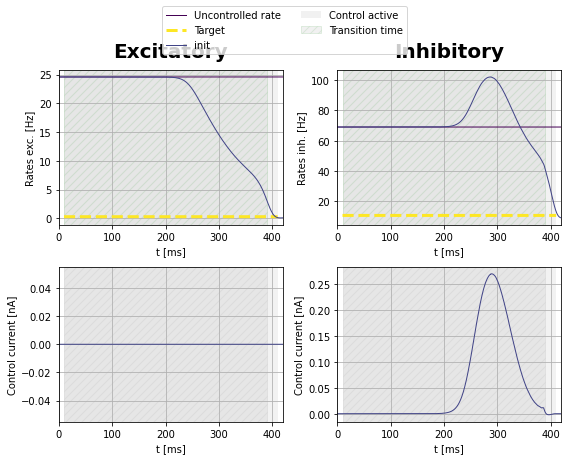

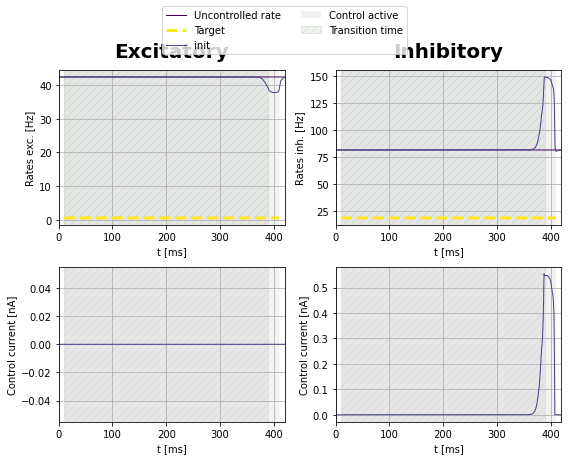

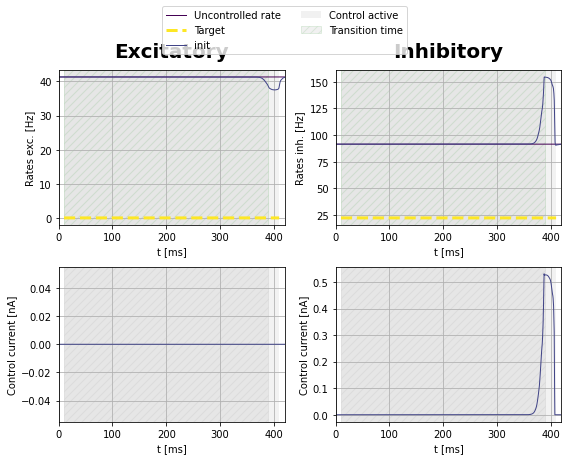

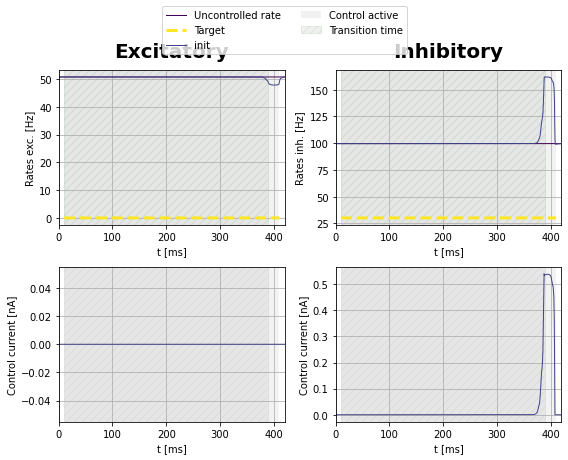

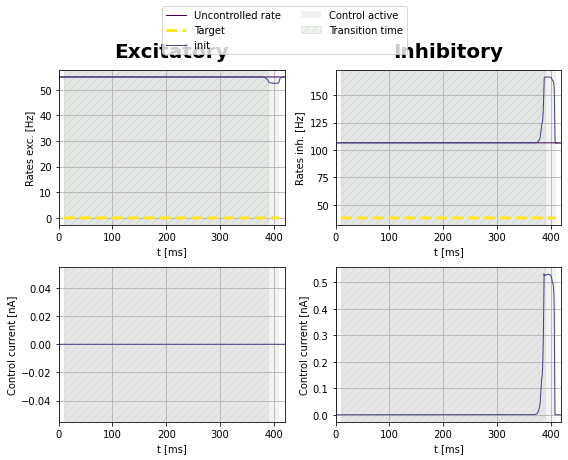

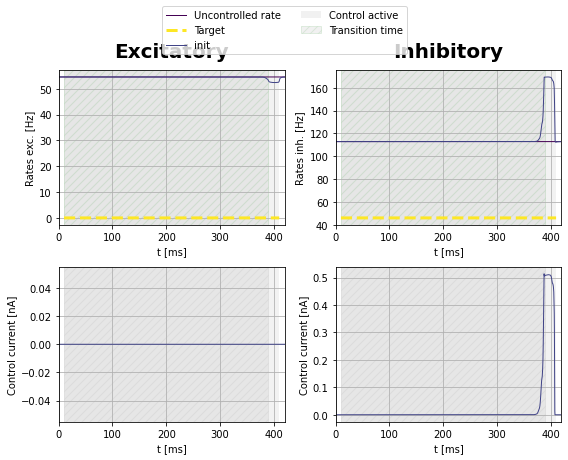

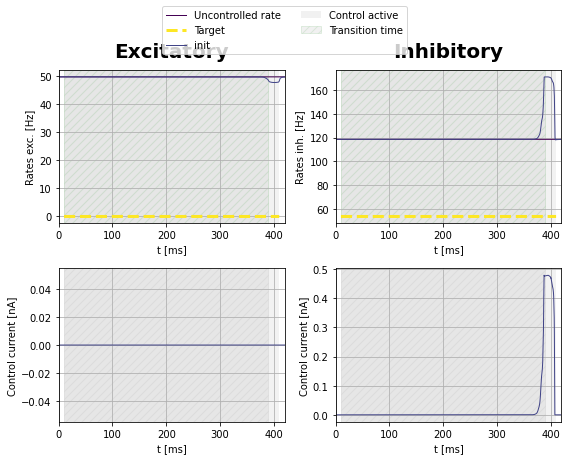

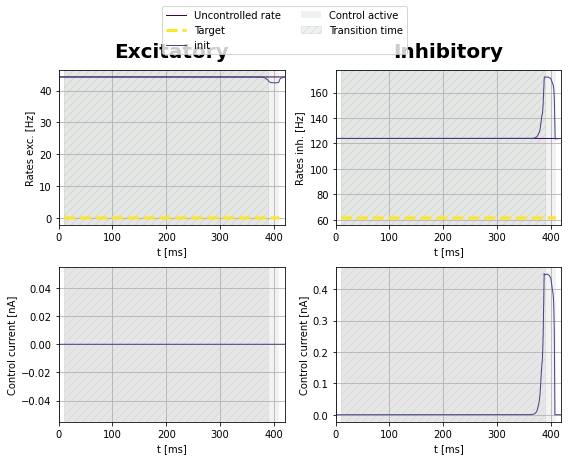

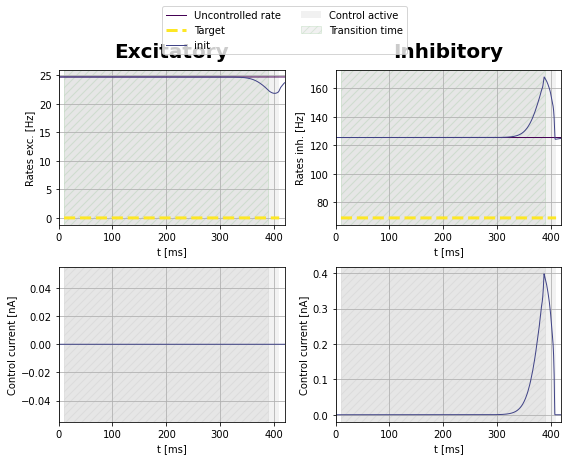

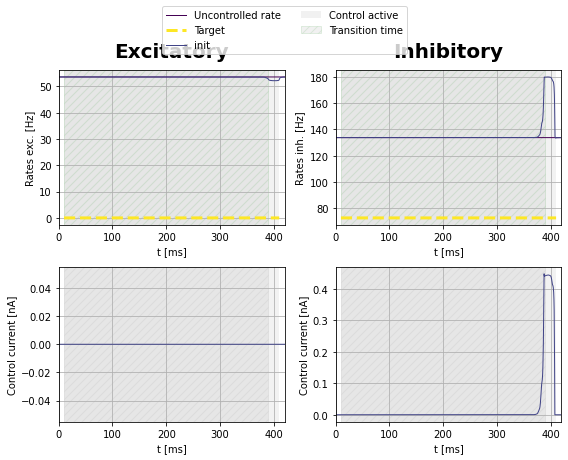

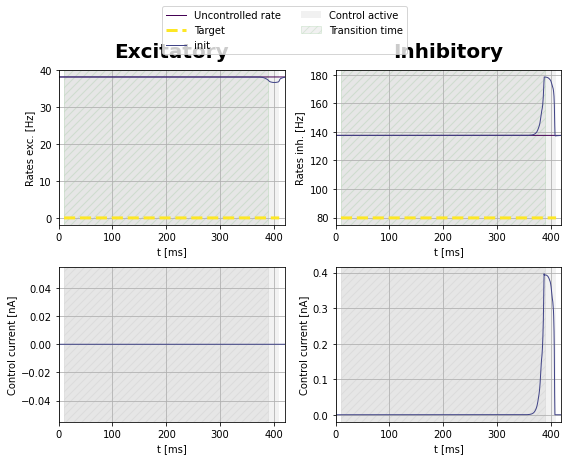

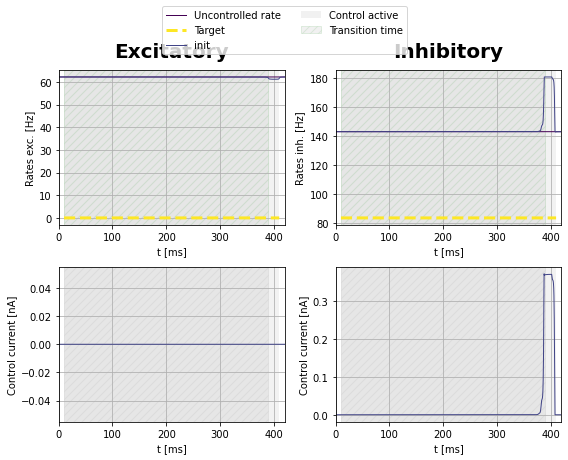

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
[0] []
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
inter

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  14766.933858342329
Control only changes marginally.
RUN  30 , total integrated cost =  14766.933858342329
Improved over  30  iterations in  2.5763659738004208  seconds by  18.203181234048856  percent.
Problem in initial value trasfer:  Vmean_exc -56.679356728153856 -56.679766302570265
weight =  11.885438095261831
set cost params:  1.0 11.885438095261831 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14931.281942854588
Gradient descend method:  None
RUN  1 , total integrated cost =  14921.14900037661
RUN  2 , total integrated cost =  14921.136252644388
RUN  3 , total integrated cost =  14921.13353640179
RUN  4 , total integrated cost =  14921.133422044448
RUN  5 , total integrated cost =  14921.133417491206
RUN  6 , total integrated cost =  14921.133416259516
RUN  7 , total integrated cost =  14921.133416046992
RUN  8 , total integrated cost =  14921.133416042738
RUN  9 , total integrated cost =  14921.133416042734
RUN  10 

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  14921.133416042725
Control only changes marginally.
RUN  12 , total integrated cost =  14921.133416042725
Improved over  12  iterations in  0.912877419963479  seconds by  0.06796822168855954  percent.
Problem in initial value trasfer:  Vmean_exc -56.679938098326964 -56.68033234708864
-------  26 0.47500000000000014 0.4750000000000002
[0] []
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17574.36538525539
Gradient descend method:  None
RUN  1 , total integrated cost =  15196.004441406783
RUN  2 , total integrated cost =  14928.6677231185
RUN  3 , total integrated cost =  14908.131826252498
RUN  4 , total integrated cost =  14907.462666299747
RUN  5 , total integrated cost =  14907.383745228097
RUN  6 , total integrated cost =  14907.355731528998
RUN  7 , total integrated cost =  14907.340674009018
RUN  8 , total integrated cost =  14907.32880504449
RUN  9 , t

...

RUN  4 , total integrated cost =  13890.973596888516
Control only changes marginally.
RUN  4 , total integrated cost =  13890.973596888516
Improved over  4  iterations in  0.7240007482469082  seconds by  0.0009046494114528514  percent.
Problem in initial value trasfer:  Vmean_exc -56.67366477651404 -56.67380339900261
-------  143 0.6000000000000003 0.8750000000000006
[0] []
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  39131.8237346285
Gradient descend method:  None
RUN  1 , total integrated cost =  37943.626496094075
RUN  2 , total integrated cost =  37902.601119755585
RUN  3 , total integrated cost =  37830.45501723414
RUN  4 , total integrated cost =  37825.161897244354
RUN  5 , total integrated cost =  37813.50711497306
RUN  6 , total integrated cost =  37811.120753170326
RUN  7 , total integrated cost =  37801.71585988549
RUN  8 , total integrated cost =  37799.349099483894
RUN  9 , tot

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  194 , total integrated cost =  37765.88285942811
Improved over  194  iterations in  22.22851363196969  seconds by  3.4906138913010807  percent.
Problem in initial value trasfer:  Vmean_exc -56.700966057789316 -56.70092151293059
weight =  10.224310687748005
set cost params:  1.0 10.224310687748005 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37773.94917637563
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  37773.94917637563
Control only changes marginally.
RUN  1 , total integrated cost =  37773.94917637563
Improved over  1  iterations in  0.3291339594870806  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700966057789316 -56.70092151293059
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  26 0.47500000000000014 0.4750000000000002
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  39 0.5250000000000001 0.5250000000000002
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  52 0.5500000000000003 0.5750000000000003
closest index  -1
set cost params:  1.0 

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  112.09200898011092
set cost params:  1.0 112.09200898011092 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5850.259729416896
Gradient descend method:  None
RUN  1 , total integrated cost =  5850.259729416894
RUN  2 , total integrated cost =  5850.259729416893


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  5850.259729416893
Control only changes marginally.
RUN  3 , total integrated cost =  5850.259729416893
Improved over  3  iterations in  0.8371481373906136  seconds by  7.105427357601002e-14  percent.
Problem in initial value trasfer:  Vmean_exc -63.76662393822485 -63.79226291154257
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  12.98037770555387
set cost params:  1.0 12.98037770555387 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15002.52010430279
Gradient descend method:  None
RUN  1 , total integrated cost =  14999.630281818256
RUN  2 , total integrated cost =  14999.610465433801
RUN  3 , total integrated cost =  14999.608467388738
RUN  4 , total integrated cost =  14999.60846738873
RUN  5 , total integrated cost =  14999.608467388729
RUN  6 , total integrated cost =  14999.608467388727


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  14999.608467388727
Control only changes marginally.
RUN  7 , total integrated cost =  14999.608467388727
Improved over  7  iterations in  1.203612508252263  seconds by  0.01940765213991824  percent.
Problem in initial value trasfer:  Vmean_exc -56.68025691981907 -56.6806450183126
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  12.017630479417857
set cost params:  1.0 12.017630479417857 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15051.8953047735
Gradient descend method:  None
RUN  1 , total integrated cost =  15051.234721982959
RUN  2 , total integrated cost =  15051.230847495115
RUN  3 , total integrated cost =  15051.229202780441
RUN  4 , total integrated cost =  15051.22919135968
RUN  5 , total integrated cost =  15051.229191060585
RUN  6 , total integrated cost =  15051.229191056264
RUN  7 , total integrated cost =  15051.229191056063
RUN  8 , total integrated cost =  15051.22919105606
RUN

...

RUN  4 , total integrated cost =  5585.660087775651
Control only changes marginally.
RUN  4 , total integrated cost =  5585.660087775651
Improved over  4  iterations in  0.7745321206748486  seconds by  0.011122458944683444  percent.
Problem in initial value trasfer:  Vmean_exc -56.622966316231825 -56.622989633430656
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  2.2837005893996687
set cost params:  1.0 2.2837005893996687 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  27355.245086260602
Gradient descend method:  None
RUN  1 , total integrated cost =  27355.235341759246
RUN  2 , total integrated cost =  27355.233948551755
RUN  3 , total integrated cost =  27355.22640846053
RUN  4 , total integrated cost =  27355.22362592088
RUN  5 , total integrated cost =  27355.218033637393
RUN  6 , total integrated cost =  27355.214724891288
RUN  7 , total integrated cost =  27355.209257907063
RUN  8 , total integrated cost =  27355.20586264879

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1627 , total integrated cost =  27349.71121444506
Improved over  1627  iterations in  156.1967167686671  seconds by  0.020229655402800972  percent.
Problem in initial value trasfer:  Vmean_exc -56.703669457262905 -56.703712282276236
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  4.154487490320306
set cost params:  1.0 4.154487490320306 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13614.711070087798
Gradient descend method:  None
RUN  1 , total integrated cost =  13614.70433617734
RUN  2 , total integrated cost =  13614.68956654965
RUN  3 , total integrated cost =  13614.683069952063
RUN  4 , total integrated cost =  13614.669045472505
RUN  5 , total integrated cost =  13614.661954768197
RUN  6 , total integrated cost =  13614.648231220448
RUN  7 , total integrated cost =  13614.639846915807
RUN  8 , total integrated cost =  13614.627131107865
RUN  9 , total integrated cost =  13614.618782

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  99 , total integrated cost =  13613.779030518654
Improved over  99  iterations in  6.989428475499153  seconds by  0.006845827020100614  percent.
Problem in initial value trasfer:  Vmean_exc -56.673146158384974 -56.67330412906286
-------  143 0.6000000000000003 0.8750000000000006
converged for  143


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  117.64115004380888
Gradient descend method:  None
RUN  1 , total integrated cost =  102.45076018001983
RUN  2 , total integrated cost =  100.09387917282179
RUN  3 , total integrated cost =  100.00951011036659
RUN  4 , total integrated cost =  99.93002933670282
RUN  5 , total integrated cost =  99.87136768760216
RUN  6 , total integrated cost =  99.82572077922808
RUN  7 , total integrated cost =  99.7566026131994
RUN  8 , total integrated cost =  99.71501232410012
RUN  9 , total integrated cost =  99.64843324696616
RUN  10 , total integrated cost =  99.60691271574629
RUN  11 , total integrated cost =  99.53804667956813
RUN  12 , total integrated cost =  99.49657829302956
RUN  13 , total integrated cost =  99.4295630012603
RUN  14 , total integrated cost =  99.3881401708569
RUN  15 , total integrated cost =  99.31907626815902
RUN  16 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  126 , total integrated cost =  8.653288123997978
Improved over  126  iterations in  32.521153908222914  seconds by  92.64433565909927  percent.
Problem in initial value trasfer:  Vmean_exc -62.79122263054518 -62.79001016502565
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37.175724724143734
Gradient descend method:  HS
RUN  1 , total integrated cost =  36.58967592785191
RUN  2 , total integrated cost =  36.54886128042223
RUN  3 , total integrated cost =  36.466298679847476
RUN  4 , total integrated cost =  36.19423123885246
RUN  5 , total integrated cost =  36.191524447274205
RUN  6 , total integrated cost =  36.19136899846211
RUN  7 , total integrated cost =  36.18965178659402
RUN  8 , total integrated cost =  36.18636630553419
RUN  9 , total integrated cost =  36.18203745811713
RUN  10 , total integrated cost =  36.179641380114084
RUN  11 , total integrated cost =  36.1787593

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  299 , total integrated cost =  35.858352587871295
Improved over  299  iterations in  90.92680407874286  seconds by  3.5436353858540173  percent.
Problem in initial value trasfer:  Vmean_exc -62.9023826597502 -62.89830992941221
weight =  16459.339232747712
set cost params:  1.0 16459.339232747712 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5884.226919827408
Gradient descend method:  None
RUN  1 , total integrated cost =  5850.769374899492
RUN  2 , total integrated cost =  5850.564001781938
RUN  3 , total integrated cost =  5850.551012589946
RUN  4 , total integrated cost =  5850.527196815787
RUN  5 , total integrated cost =  5850.522877453287
RUN  6 , total integrated cost =  5850.225947595069
RUN  7 , total integrated cost =  5850.216128814715
RUN  8 , total integrated cost =  5850.215690075946
RUN  9 , total integrated cost =  5850.21568996387
RUN  10 , total integrated cost =  5850.215689962584
RUN  11 , total inte

...

Control only changes marginally.
RUN  274 , total integrated cost =  59.83961302687273
Improved over  274  iterations in  87.92689312621951  seconds by  99.84038975138895  percent.
Problem in initial value trasfer:  Vmean_exc -63.572047316661006 -63.57851546736599
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1745.1759575551087
Gradient descend method:  HS
RUN  1 , total integrated cost =  1653.6387422402556
RUN  2 , total integrated cost =  1648.8264832517546
RUN  3 , total integrated cost =  1647.949825962039
RUN  4 , total integrated cost =  1647.9498003383928
RUN  5 , total integrated cost =  1647.861395637809
RUN  6 , total integrated cost =  1647.7424200031246
RUN  7 , total integrated cost =  1647.732761187131
RUN  8 , total integrated cost =  1647.73274931732
RUN  9 , total integrated cost =  1647.7327491652368
RUN  10 , total integrated cost =  1647.7327491075519
RUN  11 , total integrated cost =  1647.732

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  1647.7327491075494
Control only changes marginally.
RUN  12 , total integrated cost =  1647.7327491075494
Improved over  12  iterations in  3.63436989672482  seconds by  5.5835749985962195  percent.
Problem in initial value trasfer:  Vmean_exc -59.25626589034219 -59.24116940455505
weight =  2342.4025934183023
set cost params:  1.0 2342.4025934183023 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38074.27964550409
Gradient descend method:  None
RUN  1 , total integrated cost =  37297.683578026554
RUN  2 , total integrated cost =  37296.589729672945
RUN  3 , total integrated cost =  37296.05305341349
RUN  4 , total integrated cost =  37295.412845753475
RUN  5 , total integrated cost =  37295.24806193943
RUN  6 , total integrated cost =  37294.95505342315
RUN  7 , total integrated cost =  37294.804450451
RUN  8 , total integrated cost =  37294.44133969981
RUN  9 , total integrated cost =  35690.41090767642
RUN  10 , total int

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  24820.70916926353
Control only changes marginally.
RUN  15 , total integrated cost =  24820.70916926353
Improved over  15  iterations in  3.5842250213027  seconds by  34.809773420901934  percent.
Problem in initial value trasfer:  Vmean_exc -56.69992765015571 -56.70120585950142


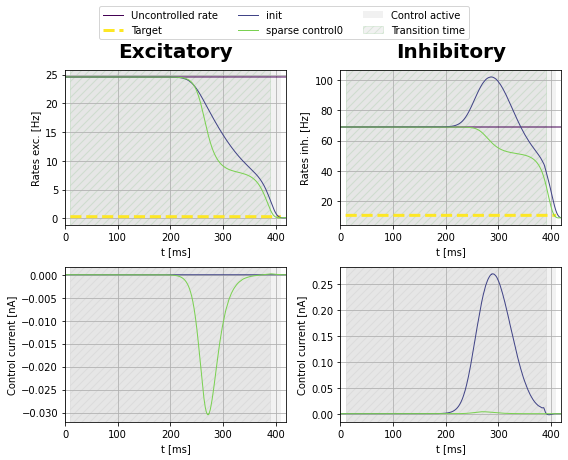

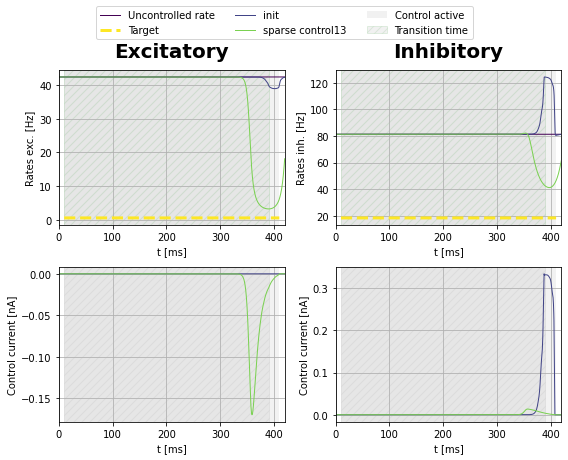

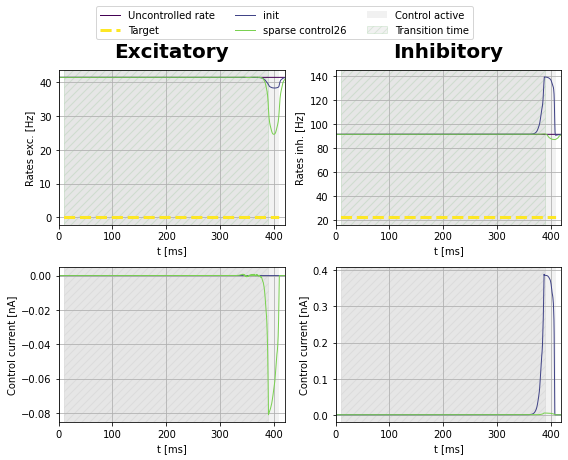

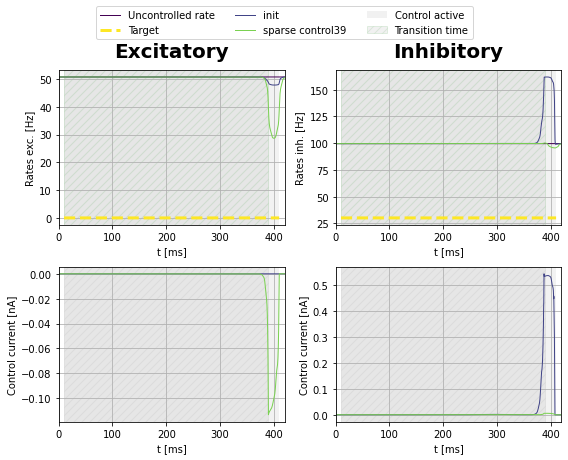

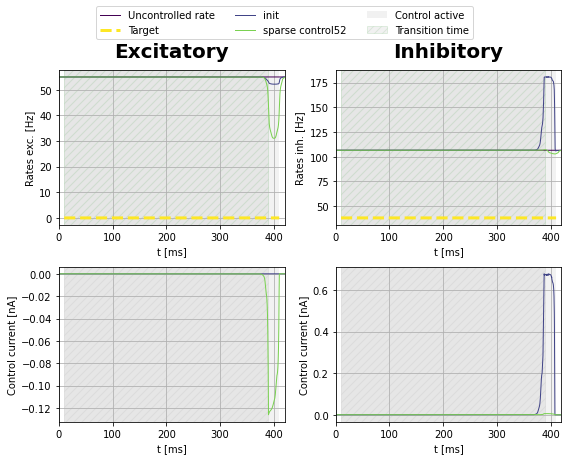

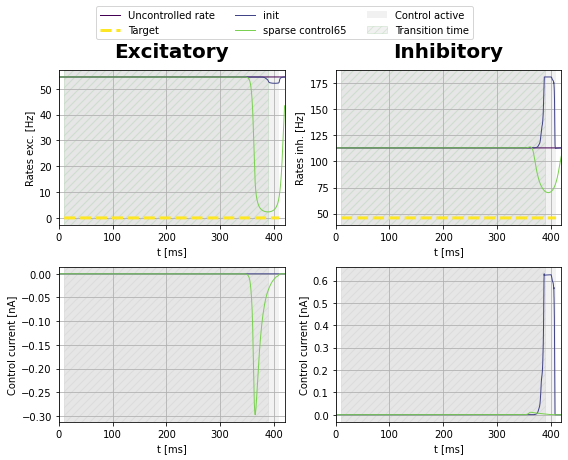

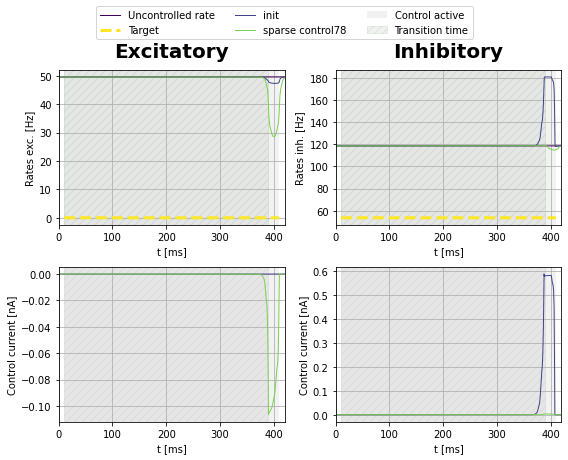

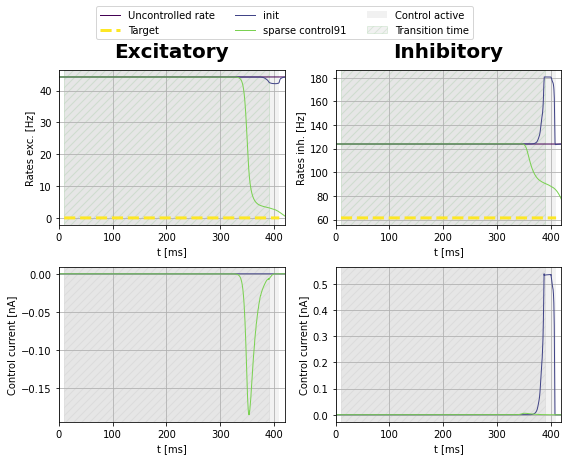

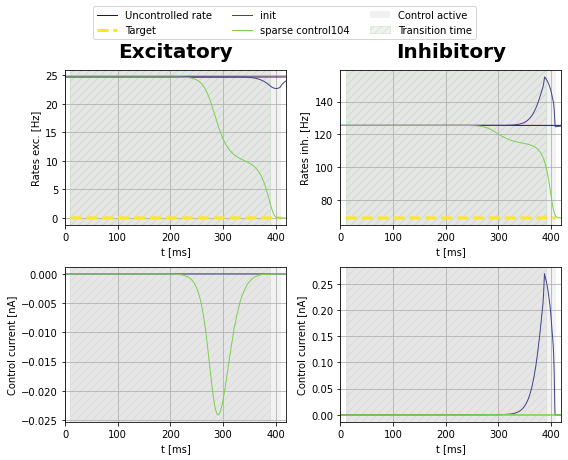

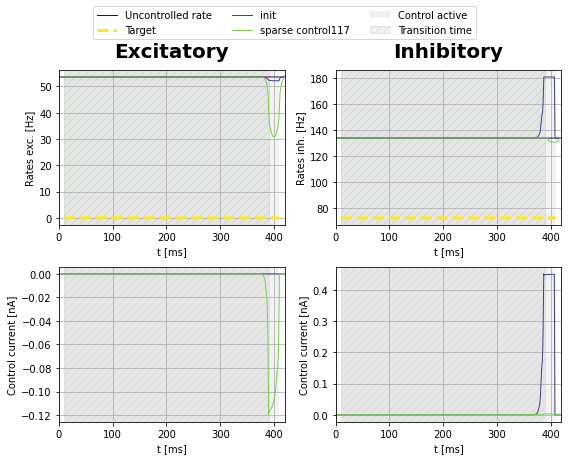

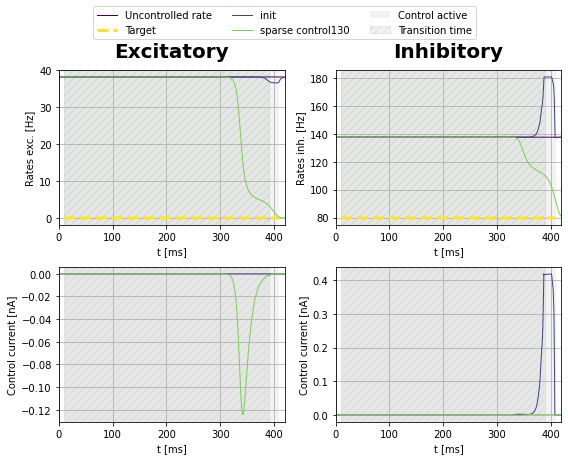

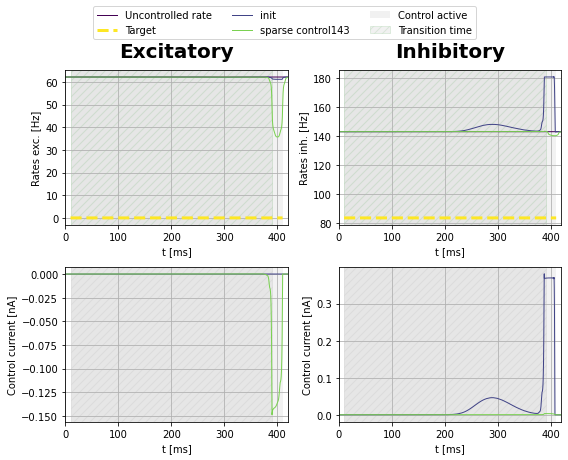

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  16605.175854000863
set cost params:  1.0 16605.175854000863 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.0358863500705
Gradient descend method:  None
RUN  1 , total integrated cost =  5542.279935739605
RUN  2 , total integrated cost =  4842.51042123743
RUN  3 , total integrated cost =  4828.010543109848
RUN  4 , total integrated cost =  4825.811398342645
RUN  5 , total integrated cost =  4825.8113669366885
RUN  6 , total integrated cost =  4825.81136693598
RUN  7 , total integrated cost =  4825.8113669359755


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  4825.8113669359755
Control only changes marginally.
RUN  8 , total integrated cost =  4825.8113669359755
Improved over  8  iterations in  2.084742808714509  seconds by  18.23480134885544  percent.
Problem in initial value trasfer:  Vmean_exc -56.62877836804986 -56.62869541659526
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  3619.1041036178226
set cost params:  1.0 3619.1041036178226 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17542.491745200525
Gradient descend method:  None
RUN  1 , total integrated cost =  17542.45243065439
RUN  2 , total integrated cost =  15504.816380192606
RUN  3 , total integrated cost =  11679.466806955475
RUN  4 , total integrated cost =  11602.095736056133
RUN  5 , total integrated cost =  11599.822083220195
RUN  6 , total integrated cost =  11597.94571621294
RUN  7 , total integrated cost =  11597.934808074024
RUN  8 , total integrated cost =  11597.934808074015
R

ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  11597.934808074013
Control only changes marginally.
RUN  10 , total integrated cost =  11597.934808074013
Improved over  10  iterations in  2.2622031532227993  seconds by  33.886616698867144  percent.
Problem in initial value trasfer:  Vmean_exc -56.656009343517596 -56.65749486819616
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  5882.821274828395
set cost params:  1.0 5882.821274828395 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13660.17837362252
Gradient descend method:  None
RUN  1 , total integrated cost =  13104.060650089361
RUN  2 , total integrated cost =  13095.936215370588
RUN  3 , total integrated cost =  13095.936185832723
RUN  4 , total integrated cost =  13095.936185787026
RUN  5 , total integrated cost =  13095.936185787019
RUN  6 , total integrated cost =  13095.936185787015


...

RUN  4 , total integrated cost =  19424.559893228958
Control only changes marginally.
RUN  4 , total integrated cost =  19424.559893228958
Improved over  4  iterations in  1.4503700751811266  seconds by  8.214700926600926e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.69356405538922 -56.69359663873093
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  129312.51759181656
set cost params:  1.0 129312.51759181656 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28443.141478667047
Gradient descend method:  None
RUN  1 , total integrated cost =  28443.116373978602
RUN  2 , total integrated cost =  28443.116373978584
RUN  3 , total integrated cost =  28443.11637397858


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  28443.11637397858
Control only changes marginally.
RUN  4 , total integrated cost =  28443.11637397858
Improved over  4  iterations in  1.351409224793315  seconds by  8.826271347572856e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70401910139888 -56.70402699083482
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
no convergence
weight =  114139.28226693202
set cost params:  1.0 114139.28226693202 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38246.184896993145
Gradient descend method:  None
RUN  1 , total integrated cost =  38246.1513321975
RUN  2 , total integrated cost =  38246.15132344032
RUN  3 , total integrated cost =  38246.15132343034


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  38246.15132343034
Control only changes marginally.
RUN  4 , total integrated cost =  38246.15132343034
Improved over  4  iterations in  1.1381343808025122  seconds by  8.778277596377393e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70061505594616 -56.70057858449887
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [True, True], [False, False], [True, True], [False, False]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5793.343930226342
Gradient descend method:  None
RUN  1 , total integrated cost =  568.9022355926987
RUN  2 , total integrated cost =  183.06115826304244
RUN  3 , total integrated cost =  127.46212904143007
RUN  4 , total integrated cost =  118.55172156494717
RUN  5 , total integrated cost =  109.0143178100273
RUN  6 , total integrated cost =  102.69600182994807
RUN  7 , total integrated cost =  96.36004019549989
RUN  8 , total integrated cost =  92.55683023174122
RUN  9 , total integrated cost =  88.72865134718478
RUN  10 , total integrated cost =  85.06318481390308
RUN  11 , total integrated cost =  81.64190407343597
RUN  12 , total integrated cost =  78.65877315850052
RUN  13 , total integrated cost =  75.86640107276162
RUN  14 , total integrated cost =  73.37334029048762
RUN  15 , total integrated cost =  71.05737298471676
RUN  16 , 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  541 , total integrated cost =  52.43852772277741
Improved over  541  iterations in  37.566994762048125  seconds by  99.09484870302308  percent.
Problem in initial value trasfer:  Vmean_exc -63.23926754794722 -63.23308413517228
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17217.037090780726
Gradient descend method:  None
RUN  1 , total integrated cost =  13036.893063448724
RUN  2 , total integrated cost =  12953.835142424312
RUN  3 , total integrated cost =  12951.840623259739
RUN  4 , total integrated cost =  12951.573168989713
RUN  5 , total integrated cost =  12951.449365768502
RUN  6 , total integrated cost =  12951.342030669322
RUN  7 , total integrated cost =  12951.258363142635
RUN  8 , total integrated cost =  12951.190589130907
RUN  9 , total integrated cost =  12951.141147042663
RUN  10 , total integrated cost =  12951.101706683197


ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  12950.997957961525
Control only changes marginally.
RUN  30 , total integrated cost =  12950.997957961525
Improved over  30  iterations in  2.0708785708993673  seconds by  24.778009772096937  percent.
Problem in initial value trasfer:  Vmean_exc -56.67133712748567 -56.67191320998449
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16746.831437381556
Gradient descend method:  None
RUN  1 , total integrated cost =  13415.808911250533
RUN  2 , total integrated cost =  13292.125456367849
RUN  3 , total integrated cost =  13291.138946966308
RUN  4 , total integrated cost =  13291.094020021026
RUN  5 , total integrated cost =  13291.046680199905
RUN  6 , total integrated cost =  13291.008467849679
RUN  7 , total integrated cost =  13290.969330396374
RUN  8 , total integrated cost =  13290.929047170162
RUN  9 , total integrated cost =  13290.885536763642
R

...

Control only changes marginally.
RUN  245 , total integrated cost =  26727.589358498277
Improved over  245  iterations in  17.08362289890647  seconds by  5.12747018619136  percent.
Problem in initial value trasfer:  Vmean_exc -56.70344549031631 -56.703502099222014
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  42.31155340652498
Gradient descend method:  None
RUN  1 , total integrated cost =  3.422001252437301
RUN  2 , total integrated cost =  3.4179946796289786
RUN  3 , total integrated cost =  3.4179946535506947
RUN  4 , total integrated cost =  3.417994653047847
RUN  5 , total integrated cost =  3.417994653039601
RUN  6 , total integrated cost =  3.4179946530393672
RUN  7 , total integrated cost =  3.4179946530393663
RUN  8 , total integrated cost =  3.417994653039364


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  3.4179946530393583
RUN  10 , total integrated cost =  3.4179946530393566
RUN  11 , total integrated cost =  3.4179946530393566
Control only changes marginally.
RUN  11 , total integrated cost =  3.4179946530393566
Improved over  11  iterations in  0.8727458398789167  seconds by  91.92184077904297  percent.
Problem in initial value trasfer:  Vmean_exc -71.0596648167834 -71.09416105032084
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37882.4625906213
Gradient descend method:  None
RUN  1 , total integrated cost =  36735.05566741636
RUN  2 , total integrated cost =  36712.9176855266
RUN  3 , total integrated cost =  36708.740000740734
RUN  4 , total integrated cost =  36707.52490946308
RUN  5 , total integrated cost =  36707.22863960863
RUN  6 , total integrated cost =  36706.876287206265
RUN  7 , total integrated cost =  36706.63173003748
RUN  8 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  166 , total integrated cost =  36692.966454099944
Improved over  166  iterations in  11.026120275259018  seconds by  3.1399651848817314  percent.
Problem in initial value trasfer:  Vmean_exc -56.701462045944666 -56.701391913934216


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  52.43852772277741
Gradient descend method:  None
RUN  1 , total integrated cost =  52.43852772277741
Control only changes marginally.
RUN  1 , total integrated cost =  52.43852772277741
Improved over  1  iterations in  0.1794733889400959  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -63.23926754794722 -63.23308413517228
-------  13 0.47500000000000014 0.40000000000000013
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True


ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  12950.997957961525
Gradient descend method:  None
RUN  1 , total integrated cost =  12950.997957961525
Control only changes marginally.
RUN  1 , total integrated cost =  12950.997957961525
Improved over  1  iterations in  0.18722675554454327  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67133712748567 -56.67191320998449
-------  26 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True


ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  17528.908164217442
Control only changes marginally.
RUN  1 , total integrated cost =  17528.908164217442
Improved over  1  iterations in  0.18618847988545895  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.688883080655216 -56.68912666725016
-------  104 0.4250000000000001 0.7750000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.2605160294749872
Gradient descend method:  None
RUN  1 , total integrated cost =  0.2605160294749872
Control only changes marginally.
RUN  1 , total integrated cost =  0.2605160294749872
Improved over  1  iterations in  0.1649450697004795  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.45818066205416 -75.4916769726143
-------  117 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  26727.58935

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  26727.589358498277
Control only changes marginally.
RUN  1 , total integrated cost =  26727.589358498277
Improved over  1  iterations in  0.1888781227171421  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70344549031631 -56.703502099222014
-------  130 0.47500000000000014 0.8500000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.4179946530393566
Gradient descend method:  None
RUN  1 , total integrated cost =  3.4179946530393566
Control only changes marginally.
RUN  1 , total integrated cost =  3.4179946530393566
Improved over  1  iterations in  0.1737057100981474  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.0596648167834 -71.09416105032084
-------  143 0.6000000000000003 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0


ERROR:root:Problem in initial value trasfer


interpolate adjoint :  True True True
RUN  0 , total integrated cost =  36692.966454099944
Gradient descend method:  None
RUN  1 , total integrated cost =  36692.966454099944
Control only changes marginally.
RUN  1 , total integrated cost =  36692.966454099944
Improved over  1  iterations in  0.18547453172504902  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.701462045944666 -56.701391913934216
--------------- 12
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
